## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [1]:
# !pip install torchsummary

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchsummary
from tqdm import tqdm
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [3]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')
        
root_path = 'fmnist'
mkdir(root_path)

Directory fmnist already exists!


In [4]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path, 
                                                        train=True, 
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path, 
                                                       train=False, 
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

In [20]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=256,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [21]:
len(fmnist_dataset_test)

10000

In [22]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([256, 1, 28, 28])
torch.Size([256])
256


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [29]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            nn.BatchNorm1d(28*28),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [30]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
       BatchNorm1d-2                  [-1, 784]           1,568
            Linear-3                  [-1, 256]         200,960
              ReLU-4                  [-1, 256]               0
            Linear-5                  [-1, 128]          32,896
              ReLU-6                  [-1, 128]               0
            Linear-7                   [-1, 64]           8,256
              ReLU-8                   [-1, 64]               0
           Dropout-9                   [-1, 64]               0
           Linear-10                   [-1, 10]             650
Total params: 244,330
Trainable params: 244,330
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 0.93
Estimated T

Your experiments come here:

In [31]:
model = TinyNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

model = model.train()
loss_hist = []
progress = tqdm(range(20))
for t in progress:
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        p = model(x)
        loss = loss_func(p, y)
        loss_hist.append(loss.detach())
        progress.desc = f"loss: {loss.item():.8f}"
        loss.backward()
    
        opt.step()
        opt.zero_grad()

loss: 0.19099872: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:53<00:00,  2.68s/it]


In [26]:
def accuracy(y_true, y_pred):
    predicted_labels = torch.argmax(y_pred, dim=1)
    correct_predictions = (predicted_labels == y_true).float()
    return correct_predictions.mean()

In [32]:
model = model.eval()
y_preds = []
y_true = []
acc = 0.0
with torch.no_grad():
    n_batches = 0
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        p = model(x)
        acc += accuracy(y, p)
        n_batches += 1

acc = acc.cpu()
acc = acc.numpy() / n_batches

In [33]:
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.896


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [81]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            nn.Linear(input_shape, 2048),
            nn.ReLU(),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [83]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                 [-1, 2048]       1,607,680
              ReLU-3                 [-1, 2048]               0
            Linear-4                 [-1, 1024]       2,098,176
              ReLU-5                 [-1, 1024]               0
            Linear-6                  [-1, 512]         524,800
              ReLU-7                  [-1, 512]               0
            Linear-8                  [-1, 256]         131,328
              ReLU-9                  [-1, 256]               0
           Linear-10                  [-1, 128]          32,896
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 64]           8,256
             ReLU-13                   [-1, 64]               0
           Linear-14                   

In [89]:
# !pip install tensorboard

In [90]:
from torch.utils.tensorboard import SummaryWriter

In [84]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train, 
                                           batch_size=16,
                                           shuffle=True,
                                           num_workers=3)

In [100]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 239607), started 0:00:49 ago. (Use '!kill 239607' to kill it.)

In [106]:
len(fmnist_dataset_train)

60000

In [108]:
writer = SummaryWriter()

model = OverfittingNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

train_loader = torch.utils.data.DataLoader(
    fmnist_dataset_train, 
    batch_size=32, 
    num_workers=3, 
    sampler=torch.utils.data.SubsetRandomSampler(range(1200))
)

progress = tqdm(range(15))
for epoch in progress:
    model = model.train()
    for i, (x, y) in enumerate(train_loader, 1):
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        
        p = model(x)
        
        train_loss = loss_func(p, y)
        train_loss.backward()

        t_acc = accuracy(y, p)
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", t_acc, epoch)
        
        opt.step()

    model = model.eval()
    eval_acc = 0.0
    with torch.no_grad():
        n_batches = 0
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            p = model(x)
            test_loss = loss_func(p, y)
            writer.add_scalar("Loss/test", test_loss, epoch)
            # test_loss_hist.append(test_loss.detach())
            eval_acc += accuracy(y, p)
            n_batches += 1
            
    eval_acc = eval_acc.cpu().numpy()
    eval_acc /= n_batches
    writer.add_scalar("Accuracy/test", eval_acc, epoch)

writer.close()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:14<00:00,  1.04it/s]


In [109]:
import pandas as pd

In [127]:
# на случай, если tensorboard не будет отображаться, построим те же графики из скачанных логов
aсс_train = pd.read_csv("logs/overfit/acc_train.csv")
acc_test = pd.read_csv("logs/overfit/acc_test.csv")
loss_train = pd.read_csv("logs/overfit/loss_train.csv")
loss_test = pd.read_csv("logs/overfit/loss_test.csv")

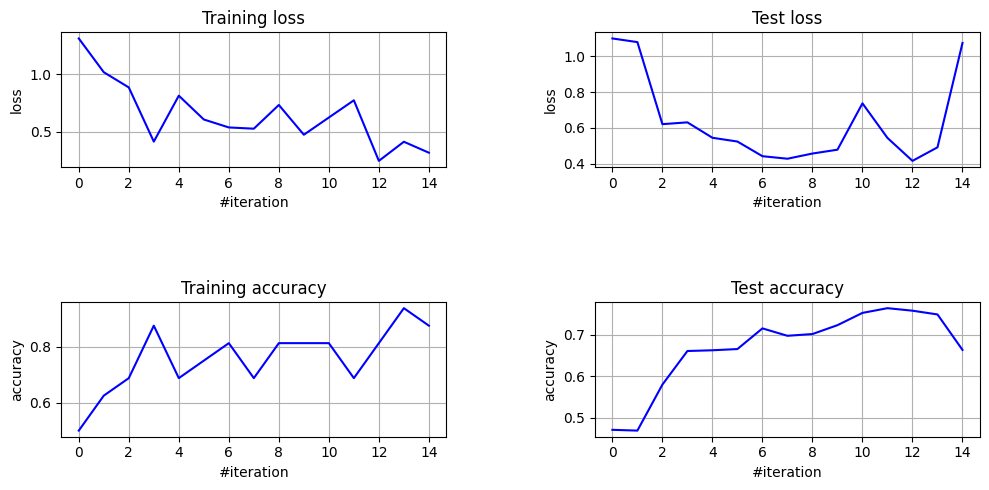

In [128]:
fig, axs = plt.subplots(2, 2, figsize=(10,5))
        
axs[0,0].set_title("Training loss")
axs[0,0].set_xlabel("#iteration")
axs[0,0].set_ylabel("loss")
axs[0,0].plot(loss_train['Value'], 'b')
axs[0,0].grid(True)

axs[0,1].set_title("Test loss")
axs[0,1].set_xlabel("#iteration")
axs[0,1].set_ylabel("loss")
axs[0,1].plot(loss_test['Value'], 'b')
axs[0,1].grid(True)

axs[1,0].set_title("Training accuracy")
axs[1,0].set_xlabel("#iteration")
axs[1,0].set_ylabel("accuracy")
axs[1,0].plot(aсс_train['Value'], 'b')
axs[1,0].grid(True)

axs[1,1].set_title("Test accuracy")
axs[1,1].set_xlabel("#iteration")
axs[1,1].set_ylabel("accuracy")
axs[1,1].plot(acc_test['Value'], 'b')
axs[1,1].grid(True)

plt.tight_layout(h_pad=5, w_pad=7)

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results. 

In [124]:
# Добавим дропаутов, батч-нормализацию и вообще уменьшим

class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            nn.BatchNorm1d(input_shape),
            nn.Linear(input_shape, 512),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, inp):       
        out = self.model(inp)
        return out

In [125]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
       BatchNorm1d-2                  [-1, 784]           1,568
            Linear-3                  [-1, 512]         401,920
           Dropout-4                  [-1, 512]               0
              ReLU-5                  [-1, 512]               0
       BatchNorm1d-6                  [-1, 512]           1,024
            Linear-7                  [-1, 256]         131,328
              ReLU-8                  [-1, 256]               0
            Linear-9                  [-1, 128]          32,896
          Dropout-10                  [-1, 128]               0
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 64]           8,256
             ReLU-13                   [-1, 64]               0
          Dropout-14                   

In [121]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 239607), started 0:24:40 ago. (Use '!kill 239607' to kill it.)

In [126]:
writer = SummaryWriter()

model = FixedNeuralNetwork().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_func = nn.CrossEntropyLoss()

train_loader = torch.utils.data.DataLoader(
    fmnist_dataset_train, 
    batch_size=64, 
    num_workers=3, 
)

progress = tqdm(range(10))
for epoch in progress:
    model = model.train()
    for i, (x, y) in enumerate(train_loader, 1):
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        
        p = model(x)
        
        train_loss = loss_func(p, y)
        train_loss.backward()

        t_acc = accuracy(y, p)
        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", t_acc, epoch)
        
        opt.step()

    model = model.eval()
    eval_acc = 0.0
    with torch.no_grad():
        n_batches = 0
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)
            p = model(x)
            test_loss = loss_func(p, y)
            writer.add_scalar("Loss/test", test_loss, epoch)
            # test_loss_hist.append(test_loss.detach())
            eval_acc += accuracy(y, p)
            n_batches += 1
            
    eval_acc = eval_acc.cpu().numpy()
    eval_acc /= n_batches
    writer.add_scalar("Accuracy/test", eval_acc, epoch)

writer.close()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:39<00:00,  3.99s/it]


In [129]:
aсс_train = pd.read_csv("logs/fix_overfit/acc_train.csv")
acc_test = pd.read_csv("logs/fix_overfit/acc_test.csv")
loss_train = pd.read_csv("logs/fix_overfit/loss_train.csv")
loss_test = pd.read_csv("logs/fix_overfit/loss_test.csv")

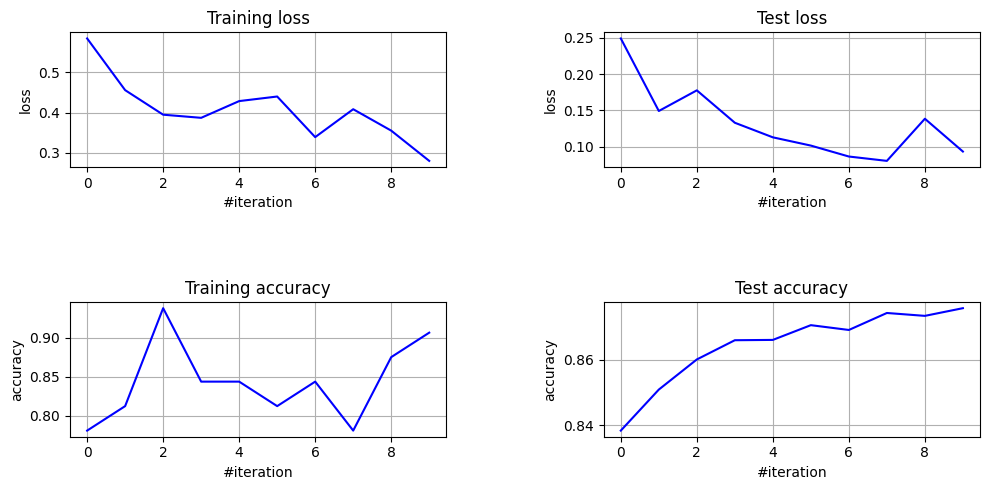

In [130]:
fig, axs = plt.subplots(2, 2, figsize=(10,5))
        
axs[0,0].set_title("Training loss")
axs[0,0].set_xlabel("#iteration")
axs[0,0].set_ylabel("loss")
axs[0,0].plot(loss_train['Value'], 'b')
axs[0,0].grid(True)

axs[0,1].set_title("Test loss")
axs[0,1].set_xlabel("#iteration")
axs[0,1].set_ylabel("loss")
axs[0,1].plot(loss_test['Value'], 'b')
axs[0,1].grid(True)

axs[1,0].set_title("Training accuracy")
axs[1,0].set_xlabel("#iteration")
axs[1,0].set_ylabel("accuracy")
axs[1,0].plot(aсс_train['Value'], 'b')
axs[1,0].grid(True)

axs[1,1].set_title("Test accuracy")
axs[1,1].set_xlabel("#iteration")
axs[1,1].set_ylabel("accuracy")
axs[1,1].plot(acc_test['Value'], 'b')
axs[1,1].grid(True)

plt.tight_layout(h_pad=5, w_pad=7)

### Conclusions:
1. Даже простой моделью можно добиться достаточно высокой точности (1 эксперимент);
2. Если данные достаточно чистые, можно обойтись без сверточных сетей;
3. На переобучение влияют следующие факторы:
    * размер модели - не стоит использовать большие модели для простых и не очень многочисленных данных;
    * использование регуляризации на уровне модели помогает справиться с переобучением, но также можно было добавить аугментации.